# Prodigy InfoTech - Task 04: Image-to-Image Translation with cGAN (Pix2Pix)

In [1]:
import os
import math
import random
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {device}')

Using Device: cpu


In [2]:
class PairedImageDataset(Dataset):
    def __init__(self, num_samples=100, img_size=64):
        self.num_samples = num_samples
        self.img_size = img_size
        self.data = []
        
        colors = [
            (220, 50, 50), (50, 180, 50), (50, 100, 220),
            (220, 180, 50), (180, 50, 220), (50, 220, 220)
        ]
        
        for i in range(num_samples):
            bg_color = (245, 245, 245)
            real_img = Image.new('RGB', (img_size, img_size), bg_color)
            edge_img = Image.new('RGB', (img_size, img_size), (255, 255, 255))
            
            draw_real = ImageDraw.Draw(real_img)
            draw_edge = ImageDraw.Draw(edge_img)
            
            shape_type = i % 4
            col = colors[i % len(colors)]
            
            if shape_type == 0:
                bbox = [12, 12, img_size - 12, img_size - 12]
                draw_real.rectangle(bbox, fill=col, outline=(30, 30, 30), width=2)
                draw_edge.rectangle(bbox, fill=(255, 255, 255), outline=(0, 0, 0), width=2)
            elif shape_type == 1:
                bbox = [12, 12, img_size - 12, img_size - 12]
                draw_real.ellipse(bbox, fill=col, outline=(30, 30, 30), width=2)
                draw_edge.ellipse(bbox, fill=(255, 255, 255), outline=(0, 0, 0), width=2)
            elif shape_type == 2:
                poly = [(img_size // 2, 10), (img_size - 10, img_size - 12), (10, img_size - 12)]
                draw_real.polygon(poly, fill=col, outline=(30, 30, 30))
                draw_edge.polygon(poly, fill=(255, 255, 255), outline=(0, 0, 0))
            else:
                bbox1 = [10, 10, img_size // 2 + 5, img_size // 2 + 5]
                bbox2 = [img_size // 2 - 5, img_size // 2 - 5, img_size - 10, img_size - 10]
                draw_real.ellipse(bbox1, fill=col, outline=(30, 30, 30))
                draw_real.rectangle(bbox2, fill=(80, 80, 80), outline=(30, 30, 30))
                draw_edge.ellipse(bbox1, fill=(255, 255, 255), outline=(0, 0, 0))
                draw_edge.rectangle(bbox2, fill=(255, 255, 255), outline=(0, 0, 0))
            
            self.data.append((edge_img, real_img))
            
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
    def __len__(self):
        return self.num_samples
        
    def __getitem__(self, idx):
        edge, real = self.data[idx]
        return self.transform(edge), self.transform(real)

dataset = PairedImageDataset(num_samples=100, img_size=64)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f'Total Paired Samples: {len(dataset)} | Batches per Epoch: {len(dataloader)}')

Total Paired Samples: 100 | Batches per Epoch: 7


In [3]:
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down1 = UNetDown(in_channels, 32, normalize=False)
        self.down2 = UNetDown(32, 64)
        self.down3 = UNetDown(64, 128)
        self.down4 = UNetDown(128, 256)
        
        self.up1 = UNetUp(256, 128, dropout=0.3)
        self.up2 = UNetUp(256, 64)
        self.up3 = UNetUp(128, 32)
        
        self.final = nn.Sequential(
            nn.ConvTranspose2d(64, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
        
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        
        u1 = self.up1(d4, d3)
        u2 = self.up2(u1, d2)
        u3 = self.up3(u2, d1)
        
        return self.final(u3)

In [4]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=1)
        )
        
    def forward(self, img_A, img_B):
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

In [5]:
generator = UNetGenerator().to(device)
discriminator = PatchGANDiscriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()
lambda_L1 = 100.0

optimizer_G = optim.Adam(generator.parameters(), lr=0.0003, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0003, betas=(0.5, 0.999))

print('Models initialized successfully!')

Models initialized successfully!


In [6]:
num_epochs = 12
loss_G_history = []
loss_D_history = []

for epoch in range(1, num_epochs + 1):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    
    for input_edges, real_images in dataloader:
        input_edges = input_edges.to(device)
        real_images = real_images.to(device)
        
        optimizer_D.zero_grad()
        fake_images = generator(input_edges)
        pred_real = discriminator(input_edges, real_images)
        loss_real = criterion_GAN(pred_real, torch.ones_like(pred_real))
        
        pred_fake = discriminator(input_edges, fake_images.detach())
        loss_fake = criterion_GAN(pred_fake, torch.zeros_like(pred_fake))
        
        loss_D = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()
        
        optimizer_G.zero_grad()
        pred_fake_for_G = discriminator(input_edges, fake_images)
        loss_GAN = criterion_GAN(pred_fake_for_G, torch.ones_like(pred_fake_for_G))
        loss_pixel = criterion_L1(fake_images, real_images)
        
        loss_G = loss_GAN + (lambda_L1 * loss_pixel)
        loss_G.backward()
        optimizer_G.step()
        
        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        
    avg_g = epoch_g_loss / len(dataloader)
    avg_d = epoch_d_loss / len(dataloader)
    loss_G_history.append(avg_g)
    loss_D_history.append(avg_d)
    
    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch [{epoch:02d}/{num_epochs:02d}] | Loss D: {avg_d:.4f} | Loss G: {avg_g:.4f}')

Epoch [01/12] | Loss D: 0.5895 | Loss G: 75.3885
Epoch [03/12] | Loss D: 0.1694 | Loss G: 42.2132
Epoch [06/12] | Loss D: 0.2830 | Loss G: 23.2578
Epoch [09/12] | Loss D: 0.2617 | Loss G: 18.3420
Epoch [12/12] | Loss D: 0.2083 | Loss G: 17.6922


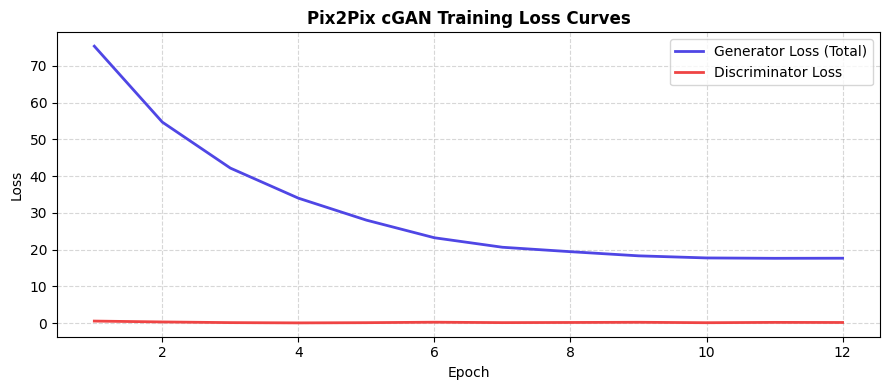

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, num_epochs + 1), loss_G_history, label='Generator Loss (Total)', color='#4F46E5', linewidth=2)
plt.plot(range(1, num_epochs + 1), loss_D_history, label='Discriminator Loss', color='#EF4444', linewidth=2)
plt.title('Pix2Pix cGAN Training Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

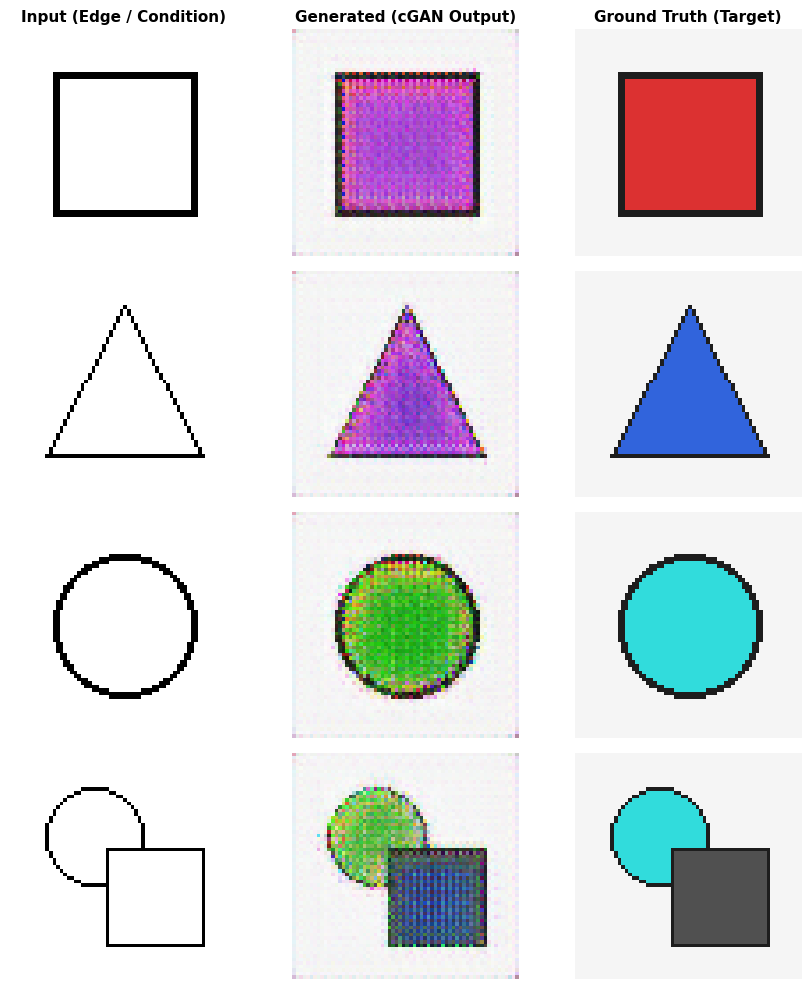

In [8]:
generator.eval()
test_loader = DataLoader(dataset, batch_size=4, shuffle=True)
test_edges, test_reals = next(iter(test_loader))

with torch.no_grad():
    generated_images = generator(test_edges.to(device)).cpu()

def unnormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(4, 3, figsize=(9, 10))
titles = ['Input (Edge / Condition)', 'Generated (cGAN Output)', 'Ground Truth (Target)']

for i in range(4):
    axes[i, 0].imshow(unnormalize(test_edges[i]))
    axes[i, 1].imshow(unnormalize(generated_images[i]))
    axes[i, 2].imshow(unnormalize(test_reals[i]))
    
    for j in range(3):
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
torch.save(generator.state_dict(), 'pix2pix_generator.pth')
torch.save(discriminator.state_dict(), 'pix2pix_discriminator.pth')
print('Models successfully serialized to pix2pix_generator.pth and pix2pix_discriminator.pth')

Models successfully serialized to pix2pix_generator.pth and pix2pix_discriminator.pth
